In [79]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
BDC_PATH    = "../data/VD_bdc_chunks.json"
#PSC_PATH    = "../data/VD_psc_chunks.json"
GT_PATH     = "../data/ir_ground_truth.json"
SCORES_DIR  = "../passim"

# Threshold grids applied to each run's scores
BDC_THRESHOLDS     = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]    # normalised
#PSC_THRESHOLDS_ABS = [5, 8, 10, 15, 20, 25, 30, 40]     # absolute tokens
BDC_MIN_TOKENS     = 8   # chunks shorter than this always kept

In [80]:
import json, statistics
from pathlib import Path
from itertools import product
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'serif',
    'axes.spines.top': False, 'axes.spines.right': False,
})
print("Ready.")

Ready.


In [98]:
def load_chunks(path):
    with open(path) as f:
        data = json.load(f)
    chunks = data.get('chunks', data) if isinstance(data, dict) else data
    print(f"  {Path(path).name}: {len(chunks):,}")
    return chunks

def token_count(c):
    tc = c.get('token_count')
    return tc if tc and isinstance(tc, int) else len(c.get('text','').split())

bdc_chunks = load_chunks(BDC_PATH)
#psc_chunks = load_chunks(PSC_PATH)
bdc_tc     = {c['chunk_id']: token_count(c) for c in bdc_chunks}
#psc_tc     = {c['chunk_id']: token_count(c) for c in psc_chunks}
bdc_text   = {c['chunk_id']: c['text'] for c in bdc_chunks}
#psc_text   = {c['chunk_id']: c['text'] for c in psc_chunks}
all_bdc_ids = {c['chunk_id'] for c in bdc_chunks}
#all_psc_ids = {c['chunk_id'] for c in psc_chunks}

# Ground Truth
with open(GT_PATH) as f:
    gt_data = json.load(f)
gt_entries   = gt_data.get('ground_truth', [])
gt_query_ids = [e['query_chunk_id'] for e in gt_entries]
gt_cand_ids  = [e.get('relevant_chunks', []) for e in gt_entries]
gt_types     = [e.get('reference_type', 'unknown') for e in gt_entries]
print(f"  {len(gt_entries)} GT entries ({gt_types.count('explicit')} explicit, {gt_types.count('implicit')} implicit)")

  VD_bdc_chunks.json: 19,466
  100 GT entries (50 explicit, 50 implicit)


In [82]:
# Load all score CSVs from the grid
scores_dir = Path(SCORES_DIR)
run_summary = pd.read_csv(scores_dir / "run_summary.csv")
print("Runs found:")
print(run_summary.to_string(index=False))

# For each run: load scores, compute normalised BDC, store
runs = {}  # label -> {'bdc_norm': dict, 'psc_raw': dict}

for _, row in run_summary.iterrows():
    label = row['label']
    bdc_path = scores_dir / f"scores_bdc_{label}.csv"
    #psc_path = scores_dir / f"scores_psc_{label}.csv"

    if not bdc_path.exists(): #or not psc_path.exists():
        print(f"  Skipping {label} — CSV not found")
        continue

    bdc_df = pd.read_csv(bdc_path)
    #psc_df = pd.read_csv(psc_path)

    # Raw scores (0 for unmatched chunks)
    bdc_raw = defaultdict(float, zip(bdc_df['chunk_id'], bdc_df['max_alignment_size']))
    #psc_raw = defaultdict(float, zip(psc_df['chunk_id'], psc_df['max_alignment_size']))

    # Normalised BDC: raw / token_count (0 for short chunks)
    bdc_norm = {
        cid: 0.0 if bdc_tc.get(cid, 1) < BDC_MIN_TOKENS
             else bdc_raw[cid] / bdc_tc.get(cid, 1)
        for cid in all_bdc_ids
    }
    #psc_raw_full = {cid: psc_raw[cid] for cid in all_psc_ids}

    runs[label] = {'bdc_norm': bdc_norm,'bdc_raw': dict(bdc_raw), 'params': row.to_dict()}
    print(f"  {label}: BDC {sum(1 for v in bdc_norm.values() if v>0):,} matched")

Runs found:
        label  n  min_match  gap  min_align  bdc_matched
n3_mm2_g50_a5  3          2   50          5           23
n3_mm3_g50_a8  3          3   50          8            0
n4_mm2_g50_a5  4          2   50          5         1100
n4_mm3_g50_a8  4          3   50          8          174
n5_mm2_g50_a5  5          2   50          5         6867
n5_mm3_g50_a8  5          3   50          8          970
  n3_mm2_g50_a5: BDC 23 matched
  Skipping n3_mm3_g50_a8 — CSV not found
  n4_mm2_g50_a5: BDC 1,097 matched
  n4_mm3_g50_a8: BDC 174 matched
  n5_mm2_g50_a5: BDC 6,818 matched
  n5_mm3_g50_a8: BDC 966 matched


In [83]:
def compute_gt_grid(bdc_norm):
    rows = []
    for t_bdc in BDC_THRESHOLDS:
        bdc_kept = {cid for cid, s in bdc_norm.items() if s < t_bdc}
        usable = l_exp = l_imp = 0
        for qid, cids, rtype in zip(gt_query_ids, gt_cand_ids, gt_types):
            if qid in bdc_kept:
                usable += 1
            else:
                if rtype == 'explicit':   l_exp += 1
                elif rtype == 'implicit': l_imp += 1
        total = len(gt_entries)
        rows.append({
            'bdc_t':         t_bdc,
            'usable_pct':    round(usable / total * 100, 1),
            'lost_explicit': l_exp,
            'lost_implicit': l_imp,
            'bdc_kept_pct':  round(len(bdc_kept) / len(bdc_norm) * 100, 1),
        })
    return pd.DataFrame(rows)

grids = {label: compute_gt_grid(d['bdc_norm']) for label, d in runs.items()}
print("GT grids computed for:", list(grids.keys()))

GT grids computed for: ['n3_mm2_g50_a5', 'n4_mm2_g50_a5', 'n4_mm3_g50_a8', 'n5_mm2_g50_a5', 'n5_mm3_g50_a8']


In [84]:
# what is the highest GT usable % achievable at any threshold?

comparison = []
for label, df in grids.items():
    best = df.loc[df['usable_pct'].idxmax()]
    params = runs[label]['params']
    comparison.append({
        'label':       label,
        'n':           int(params['n']),
        'min_match':   int(params['min_match']),
        'gap':         int(params['gap']),
        'min_align':   int(params['min_align']),
        'best_gt_pct': best['usable_pct'],
        'at_bdc_t':    best['bdc_t'],
        #'at_psc_t':    best['psc_t'],
        'bdc_kept_pct': best['bdc_kept_pct'],
        #'psc_kept_pct': best['psc_kept_pct'],
    })

df_cmp = pd.DataFrame(comparison).sort_values('best_gt_pct', ascending=False)
print("Best achievable GT survival per parameter set:")
print(df_cmp.to_string(index=False))

Best achievable GT survival per parameter set:
        label  n  min_match  gap  min_align  best_gt_pct  at_bdc_t  bdc_kept_pct
n4_mm3_g50_a8  4          3   50          8        100.0       0.9          99.3
n3_mm2_g50_a5  3          2   50          5         99.0       0.8          99.9
n5_mm3_g50_a8  5          3   50          8         97.0       0.8          96.0
n4_mm2_g50_a5  4          2   50          5         96.0       0.9          97.5
n5_mm2_g50_a5  5          2   50          5         87.0       0.9          87.5


In [85]:
# spot check BDC top10 for all runs
for label, d in runs.items():
    print(f"\n{'='*65}")
    print(f"TOP 10 BDC (normalised) — {label}")
    p = d['params']
    print(f"n={int(p['n'])} min_match={int(p['min_match'])} "
          f"gap={int(p['gap'])} min_align={int(p['min_align'])}")
    print(f"{'='*65}")
    top = sorted(d['bdc_norm'].items(), key=lambda x: x[1], reverse=True)[:10]
    for cid, score in top:
        tc = bdc_tc.get(cid, '?')
        print(f"\n  {cid}  norm={score:.3f}  tokens={tc}")
        print(f"  {bdc_text.get(cid, '')[:220]}")


TOP 10 BDC (normalised) — n3_mm2_g50_a5
n=3 min_match=2 gap=50 min_align=5

  11591_sent_139  norm=3.217  tokens=23
  sed aqua , quam dabo , ei fiet in eo fons aquae salientis in vitam aeternam [ Joh 4 , 14 ] .

  11820_sent_415  norm=1.897  tokens=39
  Quisquis autem biberit ex aqua , quam ego dabo ei , non sitiet in aeternum , sed aqua , quam ego dabo ei , fiet in eo fons aquae salientis in vitam aeternam [ Joh 4 , 13f] .

  11591_sent_137_139  norm=1.644  tokens=45
  Nunc enim dominus dicit : „Omnis , qui biberit ex aqua , quam ego dabo ei , non sitiet in aeternum ; sed aqua , quam dabo , ei fiet in eo fons aquae salientis in vitam aeternam [ Joh 4 , 14 ] .

  11591_sent_139_141  norm=1.574  tokens=47
  sed aqua , quam dabo , ei fiet in eo fons aquae salientis in vitam aeternam [ Joh 4 , 14 ] . Mox mutata dicendi figura , autem etiam eadem remanente , sed vocibus mutatis eandem rem docet et ait : „Ego sum panis vitae ;

  11820_sent_415_417  norm=1.574  tokens=47
  Quisquis autem b

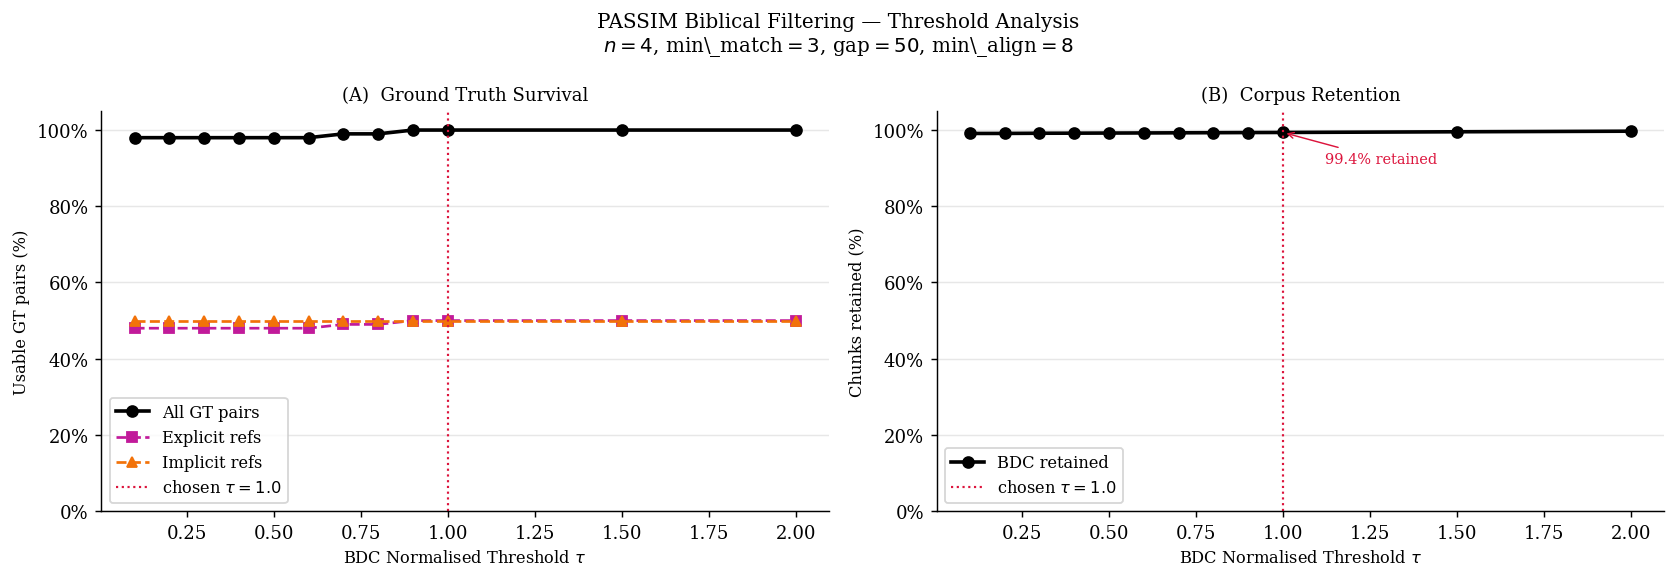

Saved: ../figures/passim_threshold_analysis.png


In [ ]:
FINAL_RUN   = "n4_mm3_g50_a8"
FINAL_BDC_T = 1.0
FINAL_PARAMS = r"$n=4$, min\_match$=3$, gap$=50$, min\_align$=8$"

BDC_THRESHOLDS_PLOT = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0]

d     = runs[FINAL_RUN]
total = len(gt_entries)


bdc_rows = []
for t in BDC_THRESHOLDS_PLOT:
    bdc_kept = {cid for cid, s in d['bdc_norm'].items() if s < t}
    usable = u_exp = u_imp = 0
    for qid, cids, rtype in zip(gt_query_ids, gt_cand_ids, gt_types):
        if qid in bdc_kept:
            usable += 1
            if rtype == 'explicit': u_exp += 1
            else:                   u_imp += 1
    bdc_rows.append({
        'threshold':       t,
        'usable_pct':      usable / total * 100,
        'usable_explicit': u_exp,
        'usable_implicit': u_imp,
        'bdc_kept_pct':    len(bdc_kept) / len(d['bdc_norm']) * 100,
    })

df_curve = pd.DataFrame(bdc_rows)


PINK   = '#C11A9A'
ORANGE = '#F27209'
VLINE  = dict(color='crimson', linestyle=':', linewidth=1.2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A — GT survival
ax = axes[0]
ax.plot(df_curve['threshold'], df_curve['usable_pct'],
        'o-', color='black', label='All GT pairs', linewidth=2)
ax.plot(df_curve['threshold'], df_curve['usable_explicit'] / total * 100,
        's--', color=PINK, label='Explicit refs', linewidth=1.5)
ax.plot(df_curve['threshold'], df_curve['usable_implicit'] / total * 100,
        '^--', color=ORANGE, label='Implicit refs', linewidth=1.5)
ax.axvline(FINAL_BDC_T, **VLINE, label=f'chosen $\\tau = {FINAL_BDC_T}$')
ax.set_xlabel('BDC Normalised Threshold $\\tau$', fontsize=9)
ax.set_ylabel('Usable GT pairs (%)', fontsize=9)
ax.set_title('(A)  Ground Truth Survival', fontsize=10)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel B — Corpus retention
ax = axes[1]
ax.plot(df_curve['threshold'], df_curve['bdc_kept_pct'],
        'o-', color='black', label='BDC retained', linewidth=2)
ax.axvline(FINAL_BDC_T, **VLINE, label=f'chosen $\\tau = {FINAL_BDC_T}$')

# annotation — find closest threshold point
closest_idx = (df_curve['threshold'] - FINAL_BDC_T).abs().idxmin()
chosen_ret  = df_curve.loc[closest_idx, 'bdc_kept_pct']
chosen_t    = df_curve.loc[closest_idx, 'threshold']
ax.annotate(
    f'{chosen_ret:.1f}% retained',
    xy=(chosen_t, chosen_ret),
    xytext=(chosen_t + 0.12, chosen_ret - 8),
    fontsize=8, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8)
)

ax.set_xlabel('BDC Normalised Threshold $\\tau$', fontsize=9)
ax.set_ylabel('Chunks retained (%)', fontsize=9)
ax.set_title('(B)  Corpus Retention', fontsize=10)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'PASSIM Biblical Filtering — Threshold Analysis\n{FINAL_PARAMS}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../figures/passim_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/passim_threshold_analysis.png")

In [87]:
comparison = []
for label, df in grids.items():
    best = df.loc[df['usable_pct'].idxmax()]
    params = runs[label]['params']
    comparison.append({
        'label':        label,
        'n':            int(params['n']),
        'min_match':    int(params['min_match']),
        'gap':          int(params['gap']),
        'min_align':    int(params['min_align']),
        'bdc_matched':  sum(1 for v in runs[label]['bdc_norm'].values() if v > 0),
        'best_gt_pct':  best['usable_pct'],
        'at_bdc_t':     best['bdc_t'],
        'bdc_kept_pct': best['bdc_kept_pct'],
    })

df_cmp = pd.DataFrame(comparison).sort_values('best_gt_pct', ascending=False)
print(df_cmp.to_string(index=False))

        label  n  min_match  gap  min_align  bdc_matched  best_gt_pct  at_bdc_t  bdc_kept_pct
n4_mm3_g50_a8  4          3   50          8          174        100.0       0.9          99.3
n3_mm2_g50_a5  3          2   50          5           23         99.0       0.8          99.9
n5_mm3_g50_a8  5          3   50          8          966         97.0       0.8          96.0
n4_mm2_g50_a5  4          2   50          5         1097         96.0       0.9          97.5
n5_mm2_g50_a5  5          2   50          5         6818         87.0       0.9          87.5


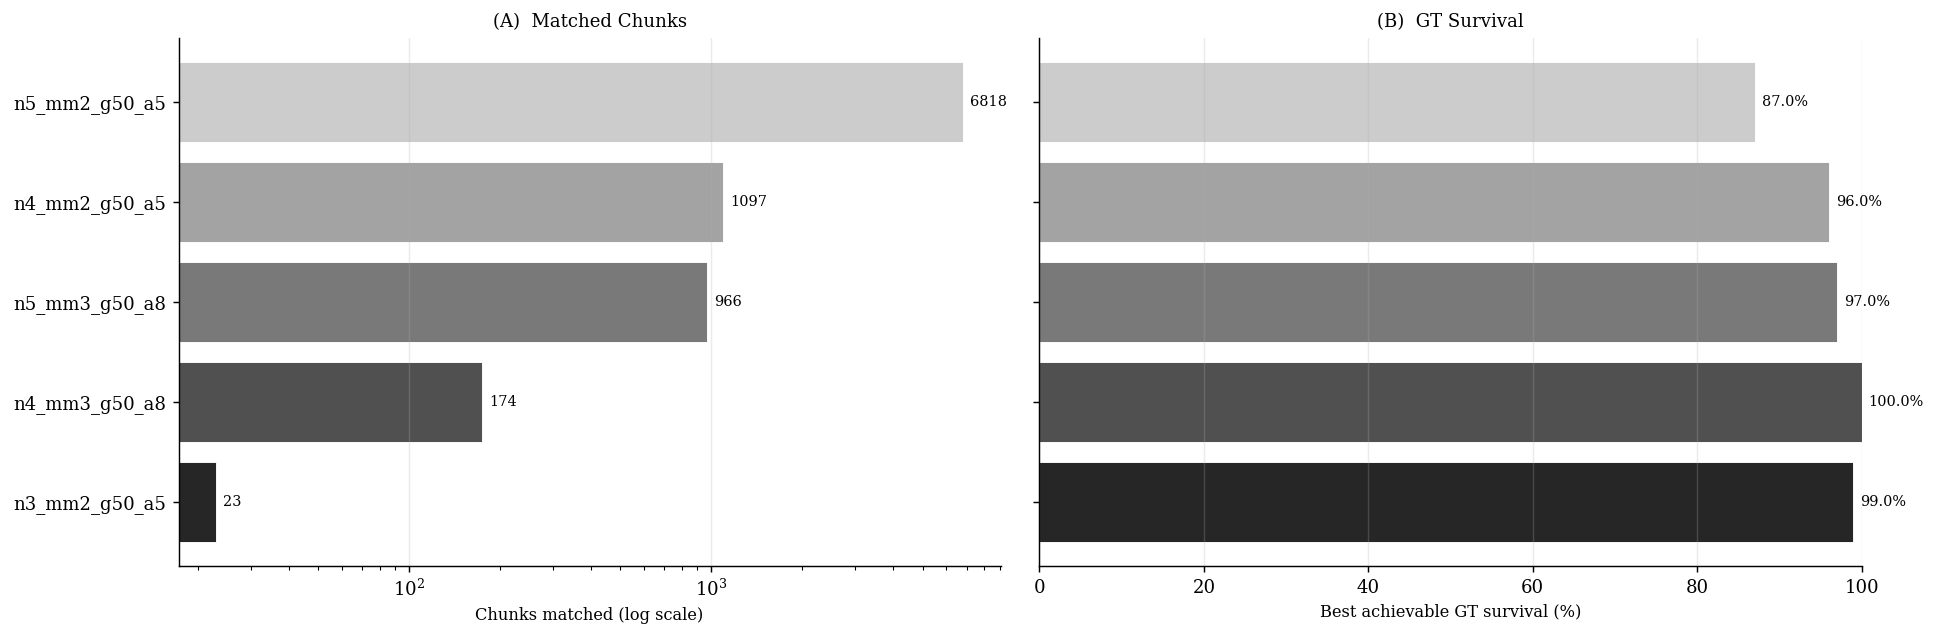

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_plot = df_cmp.sort_values('bdc_matched').reset_index(drop=True)
n = len(df_plot)
grays = [str(0.15 + 0.65 * i / (n - 1)) for i in range(n)]

# A: matched chunks (log scale)
ax = axes[0]
bars = ax.barh(df_plot['label'], df_plot['bdc_matched'],
               color=grays, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('Chunks matched (log scale)', fontsize=9)
ax.set_title('(A)  Matched Chunks', fontsize=10)
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#  B: GT survival 
ax = axes[1]
bars = ax.barh(df_plot['label'], df_plot['best_gt_pct'],
               color=grays, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=8)
ax.set_xlabel('Best achievable GT survival (%)', fontsize=9)
ax.set_title('(B)  GT Survival', fontsize=10)
ax.set_xlim(0, 100)
ax.yaxis.set_ticklabels([])
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig('../figures/passim_config_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Load raw and lemma runs
scores_dir_raw = Path("../passim/raw")
scores_dir_lemma   = Path("../passim/lemmas")

LABELS = [
    "n3_mm2_g50_a5",
    "n4_mm2_g50_a5",
    "n4_mm3_g50_a8",
    "n5_mm2_g50_a5",
    "n5_mm3_g50_a8",
]

runs_raw = {}
runs_lemma   = {}

for label in LABELS:
    for store, scores_dir in [
        (runs_raw, scores_dir_raw),
        (runs_lemma,   scores_dir_lemma),
    ]:
        path = scores_dir / f"scores_bdc_{label}.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path)
        raw = defaultdict(float, zip(df['chunk_id'], df['max_alignment_size']))
        norm = {
            cid: 0.0 if bdc_tc.get(cid, 1) < BDC_MIN_TOKENS
                 else raw[cid] / bdc_tc.get(cid, 1)
            for cid in all_bdc_ids
        }
        store[label] = {
            'bdc_norm': norm,
            'bdc_raw':  dict(raw),
            'params':   run_summary.loc[
                            run_summary['label'] == label
                        ].iloc[0].to_dict(),
        }

print("raw runs:", list(runs_raw.keys()))
print("Lemma runs:  ", list(runs_lemma.keys()))


# summary table: raw vs lemma 
rows = []
for label in LABELS:
    s = runs_raw.get(label, {}).get('bdc_norm', {})
    l = runs_lemma.get(label,   {}).get('bdc_norm', {})
    rows.append({
        'label':             label,
        'raw_matched':   sum(1 for v in s.values() if v > 0),
        'lemma_matched':     sum(1 for v in l.values() if v > 0),
        'lemma_only':        sum(
            1 for cid in all_bdc_ids
            if l.get(cid, 0.0) > 0 and s.get(cid, 0.0) == 0.0
        ),
        'raw_only':      sum(
            1 for cid in all_bdc_ids
            if s.get(cid, 0.0) > 0 and l.get(cid, 0.0) == 0.0
        ),
    })

df_comparison = pd.DataFrame(rows)
print("\nraw vs Lemma:")
print(df_comparison.to_string(index=False))

raw runs: ['n3_mm2_g50_a5', 'n4_mm2_g50_a5', 'n4_mm3_g50_a8', 'n5_mm2_g50_a5', 'n5_mm3_g50_a8']
Lemma runs:   ['n3_mm2_g50_a5', 'n4_mm2_g50_a5', 'n4_mm3_g50_a8', 'n5_mm2_g50_a5', 'n5_mm3_g50_a8']

raw vs Lemma:
        label  raw_matched  lemma_matched  lemma_only  raw_only
n3_mm2_g50_a5           23             16          12        19
n4_mm2_g50_a5         1097            791         293       599
n4_mm3_g50_a8          174             78          19       115
n5_mm2_g50_a5         6818           5677        1290      2431
n5_mm3_g50_a8          966            599         131       498


In [ ]:
Vulgate_PATH    = "../data/vulgate_chunks.json"
vulgate_chunks = load_chunks(Vulgate_PATH)

# ── Build Vulgate lookup ───────────────────────────────────────────────────
vulgate_text = {c['chunk_id']: c['text'] for c in vulgate_chunks}
vulgate_lemma = {
    c['chunk_id']: ' '.join(
        t for t in c.get('lemmatized', [])
        if t not in {',', '.', ':', ';', '!', '?', '"', "'", '-', '(', ')'}
    )
    for c in vulgate_chunks
}

# Load raw extents to get the matched Vulgate chunk_id per BDC chunk
# Surface extents
surface_extents = pd.read_csv(scores_dir_surface / f"scores_bdc_{FINAL_RUN}.csv")

  vulgate_chunks.json: 35,809


In [ ]:
# find best Vulgate verse per BDC chunk by token overlap for qualitiative analysis
from collections import Counter

def best_vulgate_match(bdc_chunk_text, vulgate_chunks, top_n=1):
    bdc_tokens = set(bdc_chunk_text.lower().split())
    scores = []
    for v in vulgate_chunks:
        v_tokens = set(v['text'].lower().split())
        overlap = len(bdc_tokens & v_tokens)
        if overlap > 0:
            scores.append((v['chunk_id'], v['text'], overlap))
    scores.sort(key=lambda x: x[2], reverse=True)
    return scores[:top_n]

def print_chunks_with_verse(label, cids, s_norm, l_norm, n=10):
    print(f"\n{'='*65}")
    print(f"{label}  (showing {min(n, len(cids))} of {len(cids)})")
    print(f"{'='*65}")
    ranked = sorted(cids,
                    key=lambda c: max(s_norm.get(c, 0.0), l_norm.get(c, 0.0)),
                    reverse=True)
    for cid in ranked[:n]:
        s = s_norm.get(cid, 0.0)
        l = l_norm.get(cid, 0.0)
        raw = bdc_text.get(cid, '')
        lemma_text = ' '.join(
            next((c['lemmatized'] for c in bdc_chunks
                  if c['chunk_id'] == cid), [])
        )
        best = best_vulgate_match(raw, vulgate_chunks, top_n=1)
        print(f"\n  {cid}")
        print(f"  raw_norm={s:.3f}  lemma_norm={l:.3f}")
        print(f"  BDC RAW:   {raw[:200]}")
        print(f"  BDC LEMMA: {lemma_text[:200]}")
        if best:
            vid, vtxt, overlap = best[0]
            print(f"  VULGATE:   [{vid}] {vtxt[:200]}")
            print(f"  (token overlap: {overlap})")

# ── Print all three categories with Vulgate ────────────────────────────────
print_chunks_with_verse(
    "CAUGHT BY BOTH — genuine verbatim quotations",
    both, s_norm, l_norm, n=10
)

print_chunks_with_verse(
    "raw ONLY — verbatim match, lemma missed",
    raw_only, s_norm, l_norm, n=10
)

print_chunks_with_verse(
    "LEMMA ONLY — morphologically adapted or CLTK artefact?",
    lemma_only, s_norm, l_norm, n=10
)


CAUGHT BY BOTH — genuine verbatim quotations  (showing 10 of 59)

  11689_sent_77
  raw_norm=5.760  lemma_norm=4.960
  BDC RAW:   Surgent enim pseudochristi et pseudoprophetae et dabunt signa magna et prodigia , ita ut in errorem inducantur , si fieri possit , etiam electi .
  BDC LEMMA: surgo enim pseudochristio et pseudopropheta et do signum magnus et prodigium , ita ut in error induco , si fio possum , etiam eligo .
  VULGATE:   [mat_24_24] Surgent enim pseudochristi, et pseudoprophetæ : et dabunt signa magna, et prodigia, ita ut in errorem inducantur (si fieri potest) etiam electi.
  (token overlap: 12)

  9183_sent_8
  raw_norm=5.000  lemma_norm=4.375
  BDC RAW:   "Bonus pastor animam suam dat pro ovibus ;
  BDC LEMMA: "Bonus pastor anima suus do pro ovus ;
  VULGATE:   [jhn_10_11] Ego sum pastor bonus. Bonus pastor animam suam dat pro ovibus suis.
  (token overlap: 6)

  11689_sent_16
  raw_norm=4.500  lemma_norm=3.812
  BDC RAW:   Venite ad me omnes , qui laboratis et onerati e